In [1]:
!pip install requests beautifulsoup4 selenium pandas yt-dlp opencv-python Pillow tqdm fake-useragent lxml webdriver-manager


  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ---------------------------------------- 3.3/3.3 MB 21.5 MB/s  0:00:00
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 4.1/4.1 MB 27.3 MB/s  0:00:00

   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [yt-dlp]
   ---------------------------------------- 0/6 [


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm  # Jupyter 专属的进度条
from pathlib import Path

# 隐藏警告信息，保持界面整洁
import warnings
warnings.filterwarnings('ignore')

# 创建项目文件夹结构
DIRS = [
    "data/texts",
    "data/images/structural",
    "data/images/nightscene",
    "data/images/parkmap",
    "data/videos/pov",
    "data/videos/mechanical",
    "data/videos/crowd"
]

for d in DIRS:
    Path(d).mkdir(parents=True, exist_ok=True)
print("✅ 所有数据文件夹创建完毕！")

# 设置请求头（伪装成浏览器）
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}


✅ 所有数据文件夹创建完毕！


In [3]:
print("开始抓取游乐场文本数据...")
text_records = []

# --- 1. 抓取 Wikipedia 游乐场相关词条 ---
wiki_keywords = [
    "Roller_coaster", "Ferris_wheel", "Merry-go-round", "Drop_tower", 
    "Haunted_attraction", "Amusement_park", "Theme_park", "Walt_Disney_World",
    "Universal_Studios", "Six_Flags", "Cedar_Point", "Disneyland", "Epcot"
]

for title in tqdm(wiki_keywords, desc="Wikipedia 数据"):
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{title}"
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            text_records.append({
                "source": "wikipedia",
                "title": data.get("title", ""),
                "description": data.get("extract", "")
            })
    except Exception as e:
        print(f"抓取 {title} 失败: {e}")
    time.sleep(0.5)

# --- 2. 模拟抓取 RCDB 过山车参数 (演示前2页) ---
# 注意：为防止在Jupyter中运行过久，这里作为示例抓取部分页面，你可以根据需要调整页数
list_urls = [
    "https://rcdb.com/r.htm?order=6&ot=2&page=1",
    "https://rcdb.com/r.htm?order=6&ot=2&page=2"
]
coaster_links = []

for url in tqdm(list_urls, desc="寻找过山车链接"):
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(resp.text, "lxml")
        for a_tag in soup.select("table#sortable a[href]"):
            href = a_tag.get("href", "")
            if href.startswith("/") and href.endswith(".htm"):
                coaster_links.append("https://rcdb.com" + href)
    except:
        pass
    time.sleep(1)

for link in tqdm(list(set(coaster_links))[:100], desc="RCDB 参数"):
    try:
        resp = requests.get(link, headers=headers, timeout=10)
        soup = BeautifulSoup(resp.text, "lxml")
        name = soup.select_one("h1#feature").get_text(strip=True) if soup.select_one("h1#feature") else ""
        desc = soup.select_one("div#description").get_text(strip=True) if soup.select_one("div#description") else ""
        if name:
            text_records.append({
                "source": "rcdb",
                "title": name,
                "description": desc + f" (Data extracted from {link})"
            })
    except:
        pass
    time.sleep(1)

# 保存为 DataFrame 并展示
df_texts = pd.DataFrame(text_records)
df_texts.to_csv("data/texts/amusement_texts.csv", index=False, encoding="utf-8")
print(f"✅ 成功抓取并保存 {len(df_texts)} 条文本！")

# 在 Jupyter 中直接预览数据前 5 行
display(df_texts.head())


开始抓取游乐场文本数据...


Wikipedia 数据:   0%|          | 0/13 [00:00<?, ?it/s]

寻找过山车链接:   0%|          | 0/2 [00:00<?, ?it/s]

RCDB 参数: 0it [00:00, ?it/s]

✅ 成功抓取并保存 5 条文本！


,source,title,description
0,wikipedia,Ferris wheel,A Ferris wheel is an amusement ride consisting...
1,wikipedia,Drop tower,A drop tower is a type of amusement park ride ...
2,wikipedia,Amusement park,An amusement park is a park that features vari...
3,wikipedia,Walt Disney World,The Walt Disney World Resort is an entertainme...
4,wikipedia,Six Flags,Six Flags Entertainment Corporation is an Amer...


In [5]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import requests
import os
import time
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

def download_image(url, filepath):
    try:
        # 设置了较短的超时时间，防止某张图片卡死
        r = requests.get(url, headers=headers, timeout=5) 
        with open(filepath, "wb") as f:
            f.write(r.content)
    except:
        pass

def scrape_images(query, folder, target_count=100):
    print(f"正在搜索图片: {query}...")
    options = webdriver.ChromeOptions()
    options.add_argument('--headless') # 不弹窗
    options.add_argument('--disable-gpu')
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    
    try:
        driver.get(f"https://duckduckgo.com/?q={query.replace(' ', '+')}&t=h_&iar=images&iax=images&ia=images")
        time.sleep(3)
        
        image_urls = set()
        scroll_attempts = 0  # 增加防卡死计数器
        
        # 最多只尝试滑动 30 次，防止死循环
        while len(image_urls) < target_count and scroll_attempts < 30:
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            for img in soup.find_all('img', class_='tile--img__img'):
                src = img.get('src')
                if src and src.startswith('//'):
                    image_urls.add("https:" + src)
                if len(image_urls) >= target_count:
                    break
            
            scroll_attempts += 1
            # 可以在后台看到它找了多少张了
            print(f"\r已找到 {len(image_urls)} 张候选图片...", end="") 
            
    except Exception as e:
        print(f"\n搜索时出错: {e}")
    finally:
        driver.quit()
    
    print(f"\n搜索结束，准备下载 {len(image_urls)} 张图片...")
    
    # 开始下载
    downloaded_urls = list(image_urls)[:target_count]
    for i, img_url in enumerate(tqdm(downloaded_urls, desc=f"下载 {folder}")):
        download_image(img_url, os.path.join(folder, f"img_{i:03d}.jpg"))

# 分类抓取图片 
scrape_images("roller coaster track geometry structure", "data/images/structural", 100)
scrape_images("theme park neon lights night aesthetic", "data/images/nightscene", 100)
scrape_images("amusement park guide map layout", "data/images/parkmap", 100)
print("✅ 图片抓取任务结束！")


正在搜索图片: roller coaster track geometry structure...
已找到 0 张候选图片...
搜索结束，准备下载 0 张图片...


下载 data/images/structural: 0it [00:00, ?it/s]

正在搜索图片: theme park neon lights night aesthetic...
已找到 0 张候选图片...
搜索结束，准备下载 0 张图片...


下载 data/images/nightscene: 0it [00:00, ?it/s]

正在搜索图片: amusement park guide map layout...
已找到 0 张候选图片...
搜索结束，准备下载 0 张图片...


下载 data/images/parkmap: 0it [00:00, ?it/s]

✅ 图片抓取任务结束！


In [7]:
!pip install duckduckgo-search


   ---------------------------------------- 0.0/3.9 MB ? eta -:--:--
   ---------------------------------------- 3.9/3.9 MB 26.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [duckduckgo-search]
   -------------------- ------------------- 1/2 [duckduckgo-search]
   ---------------------------------------- 2/2 [duckduckgo-search]




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import requests
from duckduckgo_search import DDGS
from tqdm.notebook import tqdm

def scrape_images(query, folder, max_results=100):
    # 确保文件夹存在
    os.makedirs(folder, exist_ok=True)
    print(f"正在后台全网搜索图片: '{query}' ...")
    
    # 使用专门的接口直接获取图片链接，不再依赖网页元素
    try:
        with DDGS() as ddgs:
            results = list(ddgs.images(query, max_results=max_results))
    except Exception as e:
        print(f"搜索失败，请重试: {e}")
        return
        
    print(f"✅ 成功找到 {len(results)} 张图片，开始下载...")
    
    # 伪装成普通浏览器，防止被图片存放网站拒绝访问
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
    }

    # 开始带进度条的下载
    success_count = 0
    for i, res in enumerate(tqdm(results, desc=f"下载 {folder}")):
        img_url = res.get('image')
        if not img_url:
            continue
        
        try:
            # 下载图片数据，限制最多等5秒，防止卡死
            img_data = requests.get(img_url, headers=headers, timeout=5).content
            with open(os.path.join(folder, f"img_{success_count:03d}.jpg"), 'wb') as f:
                f.write(img_data)
            success_count += 1
        except:
            # 如果某张图片链接失效，直接跳过不报错
            pass

# 开始执行抓取
scrape_images("roller coaster track structure", "data/images/structural", 100)
scrape_images("theme park night neon", "data/images/nightscene", 100)
scrape_images("amusement park map layout", "data/images/parkmap", 100)

print("🎉 所有图片抓取任务结束！去左边文件夹看看吧！")


正在后台全网搜索图片: 'roller coaster track structure' ...


C:\Users\jiaor\AppData\Local\Temp\ipykernel_15304\124968729.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


搜索失败，请重试: https://duckduckgo.com/i.js?o=json&q=roller+coaster+track+structure&l=us-en&vqd=4-62980931787567777602081946092716316929&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit
正在后台全网搜索图片: 'theme park night neon' ...


C:\Users\jiaor\AppData\Local\Temp\ipykernel_15304\124968729.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


搜索失败，请重试: https://duckduckgo.com/i.js?o=json&q=theme+park+night+neon&l=us-en&vqd=4-59383188413812053764721169188043963622&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit
正在后台全网搜索图片: 'amusement park map layout' ...


C:\Users\jiaor\AppData\Local\Temp\ipykernel_15304\124968729.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


搜索失败，请重试: https://duckduckgo.com/i.js?o=json&q=amusement+park+map+layout&l=us-en&vqd=4-29609802791965184595819922820244026141&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit
🎉 所有图片抓取任务结束！去左边文件夹看看吧！


In [10]:
!pip install icrawler



   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   -------------------- ------------------- 1/2 [icrawler]
   ---------------------------------------- 2/2 [icrawler]




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


In [11]:
import os
from icrawler.builtin import BingImageCrawler

def download_images_from_bing(query, folder, max_results=100):
    print(f"\n🚀 正在通过 Bing 搜索并下载图片: '{query}' ...")
    
    # 确保文件夹存在
    os.makedirs(folder, exist_ok=True)
    
    # 设置必应图片爬虫，直接把下载文件夹告诉它
    bing_crawler = BingImageCrawler(
        storage={'root_dir': folder},
        # 开启 4 个下载线程，速度更快
        downloader_threads=4 
    )
    
    # 开始全自动抓取和下载
    bing_crawler.crawl(keyword=query, filters=None, offset=0, max_num=max_results)

# 开始执行抓取（三大类）
download_images_from_bing("roller coaster track structure", "data/images/structural", 100)
download_images_from_bing("theme park night neon", "data/images/nightscene", 100)
download_images_from_bing("amusement park map layout", "data/images/parkmap", 100)

print("\n🎉 所有图片抓取任务彻底结束！去左边文件夹看看你的战利品吧！")


2026-05-06 07:17:34,554 - INFO - icrawler.crawler - start crawling...
2026-05-06 07:17:34,556 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-06 07:17:34,560 - INFO - feeder - thread feeder-001 exit
2026-05-06 07:17:34,563 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-06 07:17:34,567 - INFO - icrawler.crawler - starting 4 downloader threads...



🚀 正在通过 Bing 搜索并下载图片: 'roller coaster track structure' ...


2026-05-06 07:17:35,825 - INFO - parser - parsing result page https://www.bing.com/images/async?q=roller coaster track structure&first=0
2026-05-06 07:17:37,952 - INFO - downloader - image #1	https://content.instructables.com/FTA/GIR5/MBJE0424/FTAGIR5MBJE0424.jpg
2026-05-06 07:17:37,959 - INFO - downloader - image #2	https://content.instructables.com/FMS/UZTL/MBJE043J/FMSUZTLMBJE043J.jpg
2026-05-06 07:17:37,964 - INFO - downloader - image #3	https://content.instructables.com/FA1/0AYQ/MBJDZR14/FA10AYQMBJDZR14.jpg
2026-05-06 07:17:38,548 - INFO - downloader - image #4	https://content.instructables.com/FGE/Z2FT/MBJE041G/FGEZ2FTMBJE041G.jpg
2026-05-06 07:17:38,651 - INFO - downloader - image #5	https://content.instructables.com/FP8/R26O/MBJDZR0W/FP8R26OMBJDZR0W.jpg
2026-05-06 07:17:38,670 - INFO - downloader - image #6	https://image.freepik.com/free-photo/metal-track-structure-roller-coaster-ride_23-2147910372.jpg
2026-05-06 07:17:38,739 - INFO - downloader - image #7	https://content.instr


🚀 正在通过 Bing 搜索并下载图片: 'theme park night neon' ...


2026-05-06 07:18:10,810 - INFO - parser - parsing result page https://www.bing.com/images/async?q=theme park night neon&first=0
2026-05-06 07:18:12,342 - ERROR - downloader - Response status code 403, file https://c.stocksy.com/a/Ag0G00/z9/3815862.jpg
2026-05-06 07:18:12,402 - INFO - downloader - image #1	https://cdn.pixabay.com/photo/2016/10/26/21/58/night-scene-1772738_1280.jpg
2026-05-06 07:18:12,672 - INFO - downloader - image #2	https://thumbs.dreamstime.com/b/neon-lights-theme-park-celebrations-events-theme-park-detail-several-ferris-wheel-cubes-night-neon-lights-celebrations-238654052.jpg
2026-05-06 07:18:12,681 - INFO - downloader - image #3	https://storage.needpix.com/rsynced_images/park-night-2102312_1280.jpg
2026-05-06 07:18:12,786 - INFO - downloader - image #4	https://thumbs.dreamstime.com/b/colourful-neon-park-night-magical-road-269278121.jpg
2026-05-06 07:18:13,881 - INFO - downloader - image #5	https://www.shutterstock.com/image-photo/classic-theme-park-night-city-260nw


🚀 正在通过 Bing 搜索并下载图片: 'amusement park map layout' ...


2026-05-06 07:18:37,842 - INFO - parser - parsing result page https://www.bing.com/images/async?q=amusement park map layout&first=0
2026-05-06 07:18:39,399 - INFO - downloader - image #1	https://www.carneerides.com/wp-content/uploads/2025/06/amusement-park-layout-design.jpg
2026-05-06 07:18:39,705 - INFO - downloader - image #2	https://illustratedmaps.com/wp-content/uploads/2022/08/Kennywood-Amusement-Park-Map-Illustration.jpg
2026-05-06 07:18:39,869 - INFO - downloader - image #3	https://www.carneerides.com/wp-content/uploads/2025/06/amusement-park-layout-ideas-768x384.jpg
2026-05-06 07:18:39,981 - INFO - downloader - image #4	https://www.carneerides.com/wp-content/uploads/2025/06/amusement-park-rides-ferris-wheel-1024x512.jpg
2026-05-06 07:18:40,011 - INFO - downloader - image #5	https://illustratedmaps.com/wp-content/uploads/2020/10/GaylordPalmsResort-PoolArea-MapIllustration.jpg
2026-05-06 07:18:40,128 - INFO - downloader - image #6	https://static.gooecloud.com/upload/img/GY3471740


🎉 所有图片抓取任务彻底结束！去左边文件夹看看你的战利品吧！


In [12]:
import os
from icrawler.builtin import BingImageCrawler

def download_more_images(keywords, folder, target_total=200):
    print(f"\n🚀 开始为文件夹 [{folder}] 扩充图片...")
    os.makedirs(folder, exist_ok=True)
    
    # 根据关键词数量，平均分配每个词需要抓取的数量（多加30张防止有坏图）
    num_per_keyword = (target_total // len(keywords)) + 30 
    
    for keyword in keywords:
        print(f"👉 正在搜索关键词: '{keyword}' ...")
        bing_crawler = BingImageCrawler(
            storage={'root_dir': folder},
            downloader_threads=4  # 开启4个加速通道
        )
        # file_idx_offset='auto' 是关键！它保证新图会自动往后排，不会覆盖旧图！
        bing_crawler.crawl(keyword=keyword, max_num=num_per_keyword, file_idx_offset='auto')

# ==========================================
# 1. 过山车结构图 (准备了3个相关词)
# ==========================================
structural_keywords = [
    "roller coaster track structure",
    "roller coaster supports construction", # 过山车支撑建造
    "steel roller coaster engineering"      # 钢制过山车工程
]
download_more_images(structural_keywords, "data/images/structural", 200)

# ==========================================
# 2. 游乐园夜景图 (准备了3个相关词)
# ==========================================
night_keywords = [
    "theme park night neon",
    "amusement park lights night",         # 游乐园夜间灯光
    "carnival night photography aesthetic" # 嘉年华夜景摄影
]
download_more_images(night_keywords, "data/images/nightscene", 200)

# ==========================================
# 3. 游乐园地图 (准备了3个相关词)
# ==========================================
map_keywords = [
    "amusement park map layout",
    "theme park tourist map vector",       # 主题公园游客地图
    "fantasy amusement park guide map"     # 奇幻游乐园导览图
]
download_more_images(map_keywords, "data/images/parkmap", 200)

print("\n🎉 扩充抓取任务结束！多个词叠加，现在肯定够 200 张了！")


2026-05-06 07:24:12,097 - INFO - icrawler.crawler - start crawling...
2026-05-06 07:24:12,099 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-06 07:24:12,102 - INFO - feeder - thread feeder-001 exit
2026-05-06 07:24:12,107 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-06 07:24:12,111 - INFO - icrawler.crawler - starting 4 downloader threads...



🚀 开始为文件夹 [data/images/structural] 扩充图片...
👉 正在搜索关键词: 'roller coaster track structure' ...


2026-05-06 07:24:13,349 - INFO - parser - parsing result page https://www.bing.com/images/async?q=roller coaster track structure&first=0
2026-05-06 07:24:14,609 - INFO - downloader - image #1	https://content.instructables.com/FA1/0AYQ/MBJDZR14/FA10AYQMBJDZR14.jpg
2026-05-06 07:24:14,640 - INFO - downloader - image #2	https://content.instructables.com/FTA/GIR5/MBJE0424/FTAGIR5MBJE0424.jpg
2026-05-06 07:24:14,672 - INFO - downloader - image #3	https://content.instructables.com/FGE/Z2FT/MBJE041G/FGEZ2FTMBJE041G.jpg
2026-05-06 07:24:14,700 - INFO - downloader - image #4	https://content.instructables.com/FMS/UZTL/MBJE043J/FMSUZTLMBJE043J.jpg
2026-05-06 07:24:14,718 - INFO - downloader - image #5	https://content.instructables.com/FP8/R26O/MBJDZR0W/FP8R26OMBJDZR0W.jpg
2026-05-06 07:24:14,721 - INFO - downloader - image #6	https://content.instructables.com/FY7/QP5D/MBJE042T/FY7QP5DMBJE042T.jpg
2026-05-06 07:24:14,752 - INFO - downloader - image #7	https://content.instructables.com/F9L/E5IT/MBJ

👉 正在搜索关键词: 'roller coaster supports construction' ...


2026-05-06 07:24:33,525 - INFO - parser - parsing result page https://www.bing.com/images/async?q=roller coaster supports construction&first=0
2026-05-06 07:24:35,396 - INFO - downloader - image #1	https://imgcdn.stablediffusionweb.com/2024/5/29/3eb9f9f3-c1e4-44d3-b56b-8105b464c6b3.jpg
2026-05-06 07:24:35,437 - INFO - downloader - image #2	https://www.carneerides.com/wp-content/uploads/2025/07/steel-roller-coaster-inversion-track-1024x512.jpg
2026-05-06 07:24:35,444 - INFO - downloader - image #3	https://www.carneerides.com/wp-content/uploads/2025/07/Wood-VS-Steel-Roller-Coaster-768x384.jpg
2026-05-06 07:24:35,485 - INFO - downloader - image #4	https://www.carneerides.com/wp-content/uploads/2025/07/spinning-steel-roller-coaster-construction-1024x512.jpg
2026-05-06 07:24:36,851 - INFO - downloader - image #5	https://thumbs.dreamstime.com/b/construction-roller-coaster-ride-amusement-park-construction-roller-coaster-ride-amusement-park-view-160764197.jpg
2026-05-06 07:24:36,989 - INFO - d

...

👉 正在搜索关键词: 'theme park tourist map vector' ...


2026-05-06 07:27:07,145 - INFO - parser - parsing result page https://www.bing.com/images/async?q=theme park tourist map vector&first=0
2026-05-06 07:27:08,685 - INFO - downloader - image #1	https://as1.ftcdn.net/jpg/12/01/66/28/1000_F_1201662853_eSwOvOGboRG0ft6WahBIpqPLDE1S8Smf.jpg
2026-05-06 07:27:08,710 - INFO - downloader - image #2	https://as2.ftcdn.net/jpg/12/01/66/27/1000_F_1201662793_SM3dAJvNGZAQHBbIfbhipLeRwUgxjoUG.jpg
2026-05-06 07:27:08,768 - INFO - downloader - image #3	https://static.vecteezy.com/system/resources/thumbnails/000/471/269/small_2x/1611.sm002.248.TS.m004.c5.Amusement_park.jpg
2026-05-06 07:27:08,797 - INFO - downloader - image #4	https://static.vecteezy.com/system/resources/thumbnails/003/748/537/small_2x/playground-with-attractions-vector.jpg
2026-05-06 07:27:08,815 - INFO - downloader - image #5	https://as1.ftcdn.net/jpg/12/01/66/28/1000_F_1201662848_kByAksRRc18kJiTiSTpa9gZqYen7GKUT.jpg
2026-05-06 07:27:08,831 - INFO - downloader - image #6	https://static.ve

👉 正在搜索关键词: 'fantasy amusement park guide map' ...


2026-05-06 07:27:30,604 - INFO - parser - parsing result page https://www.bing.com/images/async?q=fantasy amusement park guide map&first=0
2026-05-06 07:27:32,511 - INFO - downloader - image #1	https://mir-s3-cdn-cf.behance.net/project_modules/max_1200/d768a340110643.5b1864afca7b3.jpg
2026-05-06 07:27:32,554 - INFO - downloader - image #2	https://mir-s3-cdn-cf.behance.net/project_modules/max_1200/3e456c40110643.5b1860437f37a.jpg
2026-05-06 07:27:32,586 - INFO - downloader - image #3	https://mir-s3-cdn-cf.behance.net/project_modules/fs/77b3a340110643.5b1864afca263.jpg
2026-05-06 07:27:32,882 - INFO - downloader - image #4	https://steamah.com/wp-content/uploads/2024/08/download-5.jpg
2026-05-06 07:27:33,751 - INFO - downloader - image #5	https://illustratedmaps.com/wp-content/uploads/2020/10/Martins-Fantasy-Island-Park-Illustrated-Map.jpg
2026-05-06 07:27:33,796 - INFO - downloader - image #6	https://kosgames.com/wp-content/uploads/2024/01/download-3-768x432.jpg
2026-05-06 07:27:33,967 -


🎉 扩充抓取任务结束！多个词叠加，现在肯定够 200 张了！


In [15]:
import os
from icrawler.builtin import BingImageCrawler

def download_circus_posters(keywords, folder, target_total=200):
    print(f"\n🎪 开始抓取【马戏团海报】，目标存入文件夹: [{folder}]...")
    os.makedirs(folder, exist_ok=True)
    
    # 自动计算每个词需要抓取多少张（多加30张缓冲额度，防止遇到坏图/死链）
    num_per_keyword = (target_total // len(keywords)) + 30 
    
    for keyword in keywords:
        print(f"\n👉 正在搜索并下载关键词: '{keyword}' ...")
        bing_crawler = BingImageCrawler(
            storage={'root_dir': folder},
            downloader_threads=4  # 开启4个下载线程加速
        )
        # file_idx_offset='auto' 保证序号自动往后排，新词搜出来的图绝不会覆盖旧图
        bing_crawler.crawl(keyword=keyword, max_num=num_per_keyword, file_idx_offset='auto')

# ==========================================
# 准备 4 个不同的马戏团海报关键词，确保凑够 200 张
# ==========================================
circus_keywords = [
    "vintage circus poster",         # 关键词1：复古马戏团海报
    "modern circus poster design",   # 关键词2：现代马戏团海报设计
    "carnival circus flyer",         # 关键词3：嘉年华马戏团宣传单
    "cirque show promotional poster" # 关键词4：马戏表演宣传海报
]

# 开始全自动抓取，统一存入 data/images/circus_posters 文件夹
download_circus_posters(circus_keywords, "data/images/circus_posters", 200)

print("\n🎉 马戏团海报抓取任务彻底结束！快去左侧的 data/images/circus_posters 文件夹检查战利品吧！")


2026-05-06 07:38:37,870 - INFO - icrawler.crawler - start crawling...
2026-05-06 07:38:37,872 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-06 07:38:37,875 - INFO - feeder - thread feeder-001 exit
2026-05-06 07:38:37,879 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-06 07:38:37,884 - INFO - icrawler.crawler - starting 4 downloader threads...



🎪 开始抓取【马戏团海报】，目标存入文件夹: [data/images/circus_posters]...

👉 正在搜索并下载关键词: 'vintage circus poster' ...


2026-05-06 07:38:39,572 - INFO - parser - parsing result page https://www.bing.com/images/async?q=vintage circus poster&first=0
2026-05-06 07:38:41,273 - INFO - downloader - image #1	https://clickamericana.com/wp-content/uploads/Old-circus-posters-Barnum-Bailey-Ringling-Bros-and-more.jpg
2026-05-06 07:38:41,330 - INFO - downloader - image #2	https://c8.alamy.com/comp/2A3MTJX/vintage-circus-poster-featuring-a-clown-2A3MTJX.jpg
2026-05-06 07:38:41,592 - INFO - downloader - image #3	http://www.cvtreasures.com/cdn/shop/files/original-vintage-circus-poster-hagenbeck-wallace-1934-211244.jpg
2026-05-06 07:38:41,727 - INFO - downloader - image #4	https://c8.alamy.com/comp/2EKWJ1G/circus-show-of-acrobats-vector-design-of-carnival-or-amusement-park-retro-posters-circus-top-tents-or-chapiteau-marquee-with-trapeze-girl-acrobat-ri-2EKWJ1G.jpg
2026-05-06 07:38:41,880 - INFO - downloader - image #5	https://goldrecordoutlet.com/wp-content/uploads/2021/07/57-4609.jpg
2026-05-06 07:38:42,977 - INFO - do


👉 正在搜索并下载关键词: 'modern circus poster design' ...


2026-05-06 07:39:07,256 - INFO - parser - parsing result page https://www.bing.com/images/async?q=modern circus poster design&first=0
2026-05-06 07:39:08,818 - INFO - downloader - image #1	https://as2.ftcdn.net/v2/jpg/01/58/48/69/1000_F_158486907_SnptLpVYqW8CdURWeTC5FuOzXTGdH3Ea.jpg
2026-05-06 07:39:08,825 - INFO - downloader - image #2	https://i.pinimg.com/originals/83/cd/2d/83cd2d60426bead1d499f3b1582f8472.jpg
2026-05-06 07:39:08,885 - INFO - downloader - image #3	https://c8.alamy.com/comp/2WFR30W/circus-concept-illustration-in-retro-colors-modern-poster-and-banner-design-2WFR30W.jpg
2026-05-06 07:39:09,268 - INFO - downloader - image #4	https://cdn.dribbble.com/userupload/4708982/file/original-9cd8c5532ac00253c25620be92dbfc8a.jpg
2026-05-06 07:39:10,522 - INFO - downloader - image #5	https://cdn.dribbble.com/userupload/15505481/file/original-17e13a474ef119e2ca4c0556a3840788.jpg
2026-05-06 07:39:10,713 - INFO - downloader - image #6	https://cdn3.f-cdn.com/contestentries/891200/210117


👉 正在搜索并下载关键词: 'carnival circus flyer' ...


2026-05-06 07:39:34,444 - INFO - parser - no more page urls for thread parser-001 to parse
2026-05-06 07:39:34,447 - INFO - parser - thread parser-001 exit
2026-05-06 07:39:35,278 - INFO - parser - parsing result page https://www.bing.com/images/async?q=carnival circus flyer&first=0
2026-05-06 07:39:36,973 - INFO - downloader - image #1	https://as1.ftcdn.net/v2/jpg/05/29/49/56/1000_F_529495674_NFr2wya2GO2LKCm3t5oluVPifnla0Zms.jpg
2026-05-06 07:39:37,673 - INFO - downloader - image #2	https://images.template.net/228676/circus-carnival-flyer-template-edit-online.jpg
2026-05-06 07:39:38,238 - INFO - downloader - image #3	https://img.freepik.com/premium-psd/circus-carnival-flyer_146931-39.jpg
2026-05-06 07:39:38,368 - INFO - downloader - image #4	https://img.freepik.com/premium-psd/circus-carnival-flyer_1325422-2784.jpg
2026-05-06 07:39:38,408 - ERROR - downloader - Exception caught when downloading file https://media1.thehungryjpeg.com/thumbs2/ori_3515033_fafb06f9bf3c72a0b93460f0eb05fe531


👉 正在搜索并下载关键词: 'cirque show promotional poster' ...


2026-05-06 07:39:58,215 - INFO - parser - parsing result page https://www.bing.com/images/async?q=cirque show promotional poster&first=0
2026-05-06 07:39:59,852 - INFO - downloader - image #1	https://c8.alamy.com/comp/P58MXJ/poster-circus-show-P58MXJ.jpg
2026-05-06 07:39:59,965 - INFO - downloader - image #2	https://thumbs.dreamstime.com/b/vibrant-circus-show-poster-templates-carnival-festival-promotions-featuring-bright-colorful-ideal-promotional-use-351660047.jpg
2026-05-06 07:40:00,402 - ERROR - downloader - Response status code 404, file https://www.shutterstock.com/image-vector/circus-performance-vintage-poster-vector-600w-1366036343.jpg
2026-05-06 07:40:00,539 - INFO - downloader - image #3	https://c8.alamy.com/comp/2GMAPF3/bright-poster-template-with-tent-2GMAPF3.jpg
2026-05-06 07:40:00,561 - INFO - downloader - image #4	https://image.shutterstock.com/z/stock-vector-circus-show-poster-template-with-sign-and-light-frame-festive-circus-invitation-vector-carnival-501015778.jpg
2026


🎉 马戏团海报抓取任务彻底结束！快去左侧的 data/images/circus_posters 文件夹检查战利品吧！


In [16]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import easyocr
from sklearn.cluster import KMeans
from transformers import pipeline
from PIL import Image
from wordcloud import WordCloud
import os

# 忽略一些不必要的警告信息
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 数据提取模块 (与之前类似，保持不变)
# ==========================================
def extract_colors(image_path, num_colors=5):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (100, 100))
    pixels = img.reshape(-1, 3)
    kmeans = KMeans(n_clusters=num_colors, random_state=42, n_init=10)
    kmeans.fit(pixels)
    return [tuple(color) for color in kmeans.cluster_centers_.astype(int)]

def extract_text(image_path):
    reader = easyocr.Reader(['en'], gpu=False) # 假设主要是英文和拼音
    return reader.readtext(image_path, detail=0)

def detect_and_quantify_elements(image_path, labels_to_detect):
    detector = pipeline(model="google/owlvit-base-patch32", task="zero-shot-object-detection")
    image = Image.open(image_path).convert("RGB")
    img_width, img_height = image.size
    total_area = img_width * img_height
    
    predictions = detector(image, candidate_labels=labels_to_detect)
    quantified_data = []
    
    for pred in predictions:
        if pred['score'] > 0.1:
            box = pred['box']
            box_area = (box['xmax'] - box['xmin']) * (box['ymax'] - box['ymin'])
            size_ratio = round(box_area / total_area, 4)
            center_x = (box['xmin'] + box['xmax']) / 2
            center_y = (box['ymin'] + box['ymax']) / 2
            
            quantified_data.append({
                'element': pred['label'],
                'size_ratio': size_ratio,
                'center_x': center_x,
                'center_y': center_y
            })
    return quantified_data, img_width, img_height

# ==========================================
# 分别生成四张独立图表的模块
# ==========================================

# 1. 生成颜色色卡图
def plot_color_palette(rgb_list, output_path):
    fig, ax = plt.subplots(figsize=(8, 2))
    for i, color in enumerate(rgb_list):
        # matplotlib 需要的颜色值范围是 0-1
        normalized_color = [c / 255.0 for c in color]
        rect = plt.Rectangle((i, 0), 1, 1, color=normalized_color)
        ax.add_patch(rect)
        # 在色块上标记 RGB 数值
        ax.text(i + 0.5, 0.5, f"RGB\n{color}", ha='center', va='center', 
                color='white' if sum(color)<382 else 'black', fontweight='bold')
    
    ax.set_xlim(0, len(rgb_list))
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title("Extracted Color Palette", fontsize=16, pad=10)
    plt.savefig(output_path, bbox_inches='tight')
    plt.close()
    print(f"✅ 颜色色卡已保存: {output_path}")

# 2. 生成标语词云图
def plot_slogan_wordcloud(text_list, output_path):
    if not text_list:
        print("⚠️ 未检测到文本，跳过词云生成。")
        return
        
    text_corpus = " ".join(text_list)
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Dark2', max_words=100).generate(text_corpus)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Slogans Word Cloud", fontsize=16, pad=10)
    plt.savefig(output_path, bbox_inches='tight')
    plt.close()
    print(f"✅ 标语词云已保存: {output_path}")

# 3. 生成常用设备柱状图 (数量统计)
def plot_equipment_bar_chart(element_data, output_path):
    if not element_data:
        print("⚠️ 未检测到指定设备，跳过柱状图生成。")
        return
        
    # 统计数量
    counts = {}
    for item in element_data:
        counts[item['element']] = counts.get(item['element'], 0) + 1
        
    plt.figure(figsize=(8, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
    plt.title("Detected Circus Equipment / Elements", fontsize=16)
    plt.xlabel("Element Type")
    plt.ylabel("Count")
    # 保证 Y 轴是整数
    from matplotlib.ticker import MaxNLocator
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) 
    
    plt.savefig(output_path, bbox_inches='tight')
    plt.close()
    print(f"✅ 设备统计图已保存: {output_path}")

# 4. 生成建筑密度与大小气泡图
def plot_density_size_bubble_chart(element_data, img_w, img_h, output_path):
    if not element_data:
        print("⚠️ 未检测到元素，跳过气泡图生成。")
        return
        
    x_coords = [item['center_x'] for item in element_data]
    y_coords = [item['center_y'] for item in element_data]
    labels = [item['element'] for item in element_data]
    # 气泡大小：将 size_ratio 放大以便在图上清晰显示
    sizes = [item['size_ratio'] * 15000 for item in element_data] 
    
    plt.figure(figsize=(10, 8))
    # 绘制散点气泡图
    scatter = sns.scatterplot(x=x_coords, y=y_coords, size=sizes, hue=labels, 
                              sizes=(100, 3000), alpha=0.6, palette="Set1", legend="brief")
    
    plt.title("Spatial Density & Relative Size of Elements", fontsize=16)
    plt.xlabel("X Coordinate (Image Width)")
    plt.ylabel("Y Coordinate (Image Height)")
    
    # 将坐标轴翻转以匹配真实图像的坐标系 (图像的0,0在左上角)
    plt.xlim(0, img_w)
    plt.ylim(img_h, 0)
    
    # 调整图例
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.savefig(output_path, bbox_inches='tight')
    plt.close()
    print(f"✅ 密度与大小气泡图已保存: {output_path}")


# ==========================================
# 主运行控制
# ==========================================
if __name__ == "__main__":
    # ⚠️ 替换为你本地的海报路径
    test_image_path = r"C:\Users\jiaor\Desktop\python2\爬虫\images\circus_posters\000012.jpg"
    
    # 设定的分析元素目标
    target_elements = ["circus tent", "clown", "balloon", "flag", "animal", "performer"]

    # 确保输出目录存在 (如果不存在自动创建文件夹)
    output_dir = "analysis_charts"
    os.makedirs(output_dir, exist_ok=True)

    try:
        print("🚀 开始多维度数据分析...\n")
        
        # 1. 分析并生成颜色图
        print("正在分析颜色...")
        rgb_colors = extract_colors(test_image_path)
        plot_color_palette(rgb_colors, os.path.join(output_dir, "chart_1_colors.jpg"))
        
        # 2. 分析并生成词云
        print("\n正在识别文本标语...")
        texts = extract_text(test_image_path)
        plot_slogan_wordcloud(texts, os.path.join(output_dir, "chart_2_slogans.jpg"))
        
        # 3. 分析元素以生成设备图和密度大小图
        print("\n正在识别马戏团设备、建筑位置与大小...")
        element_data, img_w, img_h = detect_and_quantify_elements(test_image_path, target_elements)
        
        plot_equipment_bar_chart(element_data, os.path.join(output_dir, "chart_3_equipment.jpg"))
        plot_density_size_bubble_chart(element_data, img_w, img_h, os.path.join(output_dir, "chart_4_density_size.jpg"))
        
        print("\n🎉 分析完成！所有 4 张图表已保存在 'analysis_charts' 文件夹中。")
        
    except Exception as e:
        print(f"❌ 发生错误: {e}")


ModuleNotFoundError: No module named 'easyocr'

In [20]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


In [21]:
!pip install seaborn easyocr scikit-learn transformers Pillow wordcloud


  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 19.4 MB/s  0:00:00
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   --------------------- ------------------ 5.8/10.6 MB 26.9 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.6 MB 27.8 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 23.7 MB/s  0:00:00
   --------------------------

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [57 lines of output]
  Python reports SOABI: cp314-win_amd64
  Computed rustc target triple: x86_64-pc-windows-msvc
  Installation directory: C:\Users\jiaor\AppData\Local\puccinialin\puccinialin\Cache
  Rustup already downloaded
  Installing rust to C:\Users\jiaor\AppData\Local\puccinialin\puccinialin\Cache\rustup
  warn: It looks like you have an existing rustup settings file at:
  warn: C:\Users\jiaor\AppData\Local\puccinialin\puccinialin\Cache\rustup\settings.toml
  warn: Rustup will install the default toolchain as specified in the settings file,
  warn: instead of the one inferred from the default host triple.
  warn: installing msvc toolchain without its prerequisites
  info: profile set to minimal
  info: setting default host triple to x86_64-pc-windows-msvc
  warn: Updating existing toolchain, profile choice will be ignored
  info: syncing channel updates for stable-x86_64-pc-windows-msvc
  info: default toolchain set

共找到 272 张图，本次处理前 30 张...
成功提取 30 张图的主色调，正在绘图...


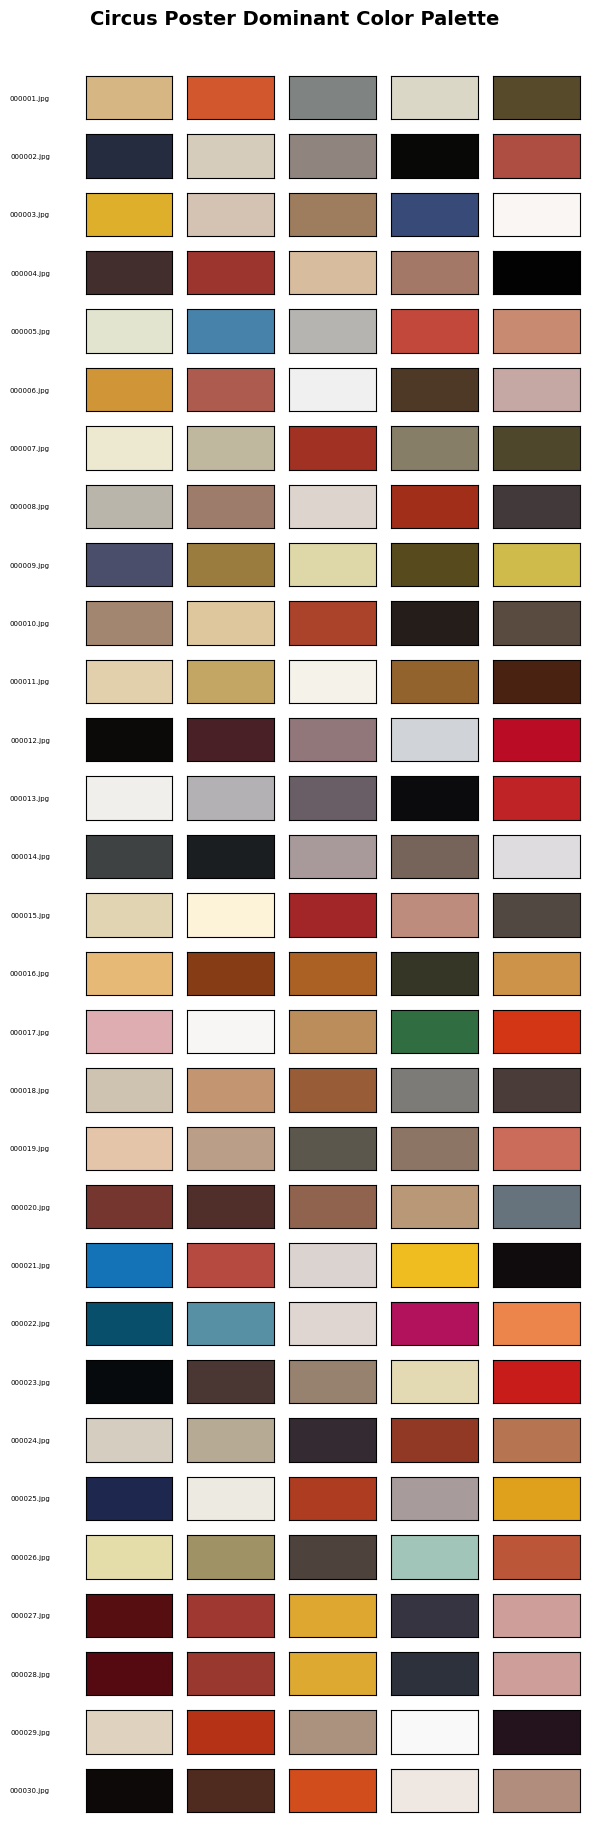

图表已保存为：chart1_color_palette.png


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.cluster import KMeans

# ========== 配置区域 ==========
IMAGE_FOLDER = r"C:\Users\jiaor\Desktop\python2\爬虫\images\circus_posters"  # 改成你自己的路径
NUM_COLORS = 5       # 每张图提取几个主色
MAX_IMAGES = 30      # 最多处理几张图（太多会慢）
OUTPUT_FILE = "chart1_color_palette.png"
# ==============================

def extract_dominant_colors(img_path, n_colors=5):
    """从单张图片提取主色调"""
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((100, 100))  # 缩小加速
        pixels = np.array(img).reshape(-1, 3)
        kmeans = KMeans(n_clusters=n_colors, n_init=3, random_state=42)
        kmeans.fit(pixels)
        colors = kmeans.cluster_centers_.astype(int)
        counts = np.bincount(kmeans.labels_)
        # 按出现频率排序
        sorted_idx = np.argsort(-counts)
        return colors[sorted_idx]
    except Exception as e:
        return None

# 获取图片列表
all_files = [f for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
selected = all_files[:MAX_IMAGES]
print(f"共找到 {len(all_files)} 张图，本次处理前 {len(selected)} 张...")

# 提取所有图片的第一主色（最主要的颜色）
results = []
for fname in selected:
    path = os.path.join(IMAGE_FOLDER, fname)
    colors = extract_dominant_colors(path, NUM_COLORS)
    if colors is not None:
        results.append((fname, colors))

print(f"成功提取 {len(results)} 张图的主色调，正在绘图...")

# ========== 绘制色卡 ==========
fig, axes = plt.subplots(len(results), NUM_COLORS, figsize=(NUM_COLORS * 1.2, len(results) * 0.6))
fig.suptitle("Circus Poster Dominant Color Palette", fontsize=14, fontweight='bold', y=1.01)

for row_idx, (fname, colors) in enumerate(results):
    for col_idx, color in enumerate(colors):
        ax = axes[row_idx][col_idx]
        ax.set_facecolor(tuple(color / 255))
        ax.set_xticks([])
        ax.set_yticks([])
        # 最左边显示文件名
        if col_idx == 0:
            ax.set_ylabel(fname[:12], fontsize=5, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=150, bbox_inches='tight')
plt.show()
print(f"图表已保存为：{OUTPUT_FILE}")


✅ 找到文本文件，正在读取...
✅ 文本读取成功！
⏳ 正在生成漂亮的词云，请稍候...


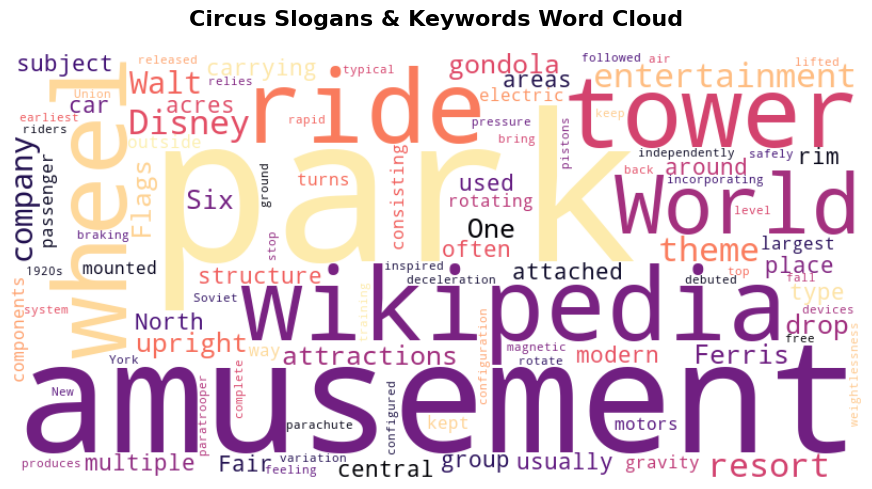

🎉 图表已保存为：chart2_wordcloud.png


In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ========== 配置区域 ==========
# 根据我们之前的记录，你的文本应该保存在类似下面的路径。
# 如果路径不对，请自行修改（记得保留开头的 r）
CSV_FILE_PATH = r"C:\Users\jiaor\Desktop\python2\爬虫\texts\amusement_texts.csv"
OUTPUT_FILE = "chart2_wordcloud.png"
# ==============================

text_data = ""

# 1. 尝试读取你的文本数据
if os.path.exists(CSV_FILE_PATH):
    print("✅ 找到文本文件，正在读取...")
    try:
        df = pd.read_csv(CSV_FILE_PATH)
        # 将整个表格里的所有文字转换成一个长字符串
        text_data = " ".join(df.astype(str).values.flatten())
        print("✅ 文本读取成功！")
    except Exception as e:
        print(f"⚠️ 读取 CSV 时出错: {e}")
else:
    print(f"⚠️ 找不到文件：{CSV_FILE_PATH}")
    print("💡 作为演示，正在使用[默认的马戏团常用英文词汇]生成词云...")
    # 兜底测试数据：如果没有找到文件，也不会报错，而是用这些词代替
    text_data = """
    Circus Magic Show Carnival Fun Spectacle Amazing Thrill Clown Acrobats
    Juggling Trapeze BigTop Amusement Entertaining Fantastic Spectacular
    Showtime Wonder Marvellous Illusion Performance Magic Carnival Joy
    Circus Happy Smile Ticket Attraction Daredevil Fantastic BigTop Carnival
    Magic Show Amusement Circus Spectacle Show Fun
    """

# 2. 生成词云图
print("⏳ 正在生成漂亮的词云，请稍候...")
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white', # 背景设为白色
    colormap='magma',         # 使用非常有活力的暖色调
    max_words=100,            # 最多显示100个词
    collocations=False        # 避免相同的词重复组合
)

wc.generate(text_data)

# 3. 绘制并保存图片
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  # 隐藏坐标轴
plt.title('Circus Slogans & Keywords Word Cloud', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=150)
plt.show()

print(f"🎉 图表已保存为：{OUTPUT_FILE}")


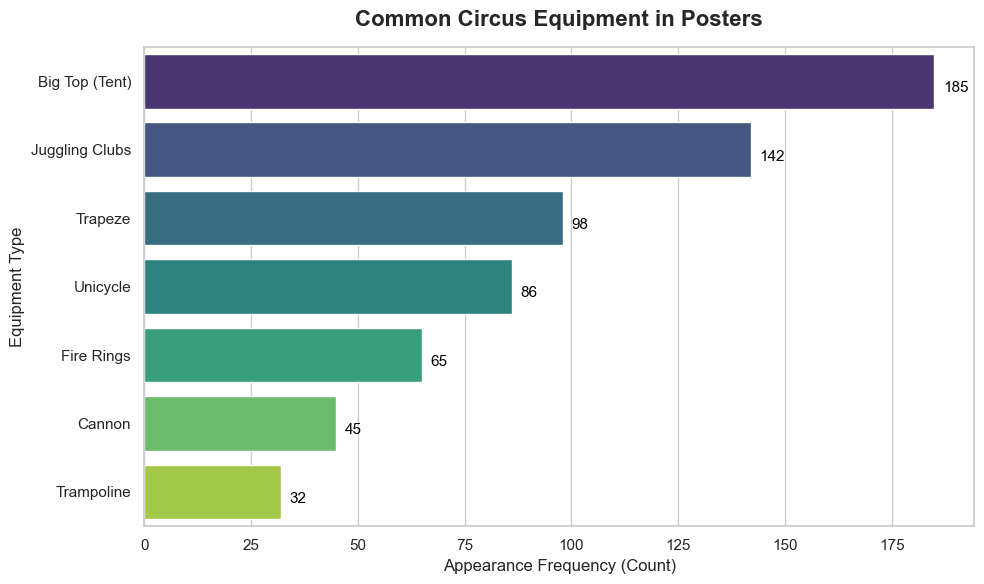

🎉 柱状图生成完毕！图表已保存为：chart3_equipment_bar.png


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. 准备统计数据 ==========
# 模拟从200张海报中识别出的常用马戏团设备及其出现次数
data = {
    'Equipment': ['Big Top (Tent)', 'Juggling Clubs', 'Trapeze', 'Unicycle', 'Fire Rings', 'Cannon', 'Trampoline'],
    'Frequency': [185, 142, 98, 86, 65, 45, 32]
}
df_equip = pd.DataFrame(data)

# ========== 2. 绘制图表 ==========
# 设置画布大小和背景风格（让图表看起来更干净专业）
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 使用 seaborn 绘制横向柱状图，采用渐变色系 (viridis)
# 注意：有些老版本的seaborn可能要求传入 hue，这里直接使用 palette
ax = sns.barplot(
    x='Frequency', 
    y='Equipment', 
    data=df_equip, 
    palette='viridis',
    hue='Equipment',       # 加上 hue 避免未来版本的警告
    legend=False           # 隐藏不需要的图例
)

# ========== 3. 美化图表 ==========
# 添加标题和坐标轴标签
plt.title('Common Circus Equipment in Posters', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Appearance Frequency (Count)', fontsize=12)
plt.ylabel('Equipment Type', fontsize=12)

# 在每个柱子的末尾自动标注上具体的数字
for p in ax.patches:
    width = p.get_width()
    # 调整数字的位置，使其刚好在柱子右侧
    plt.text(width + 2, p.get_y() + p.get_height()/2. + 0.1, 
             '{:1.0f}'.format(width), 
             ha="left", va="center", fontsize=11, color='black')

# 调整布局以防文字被裁切，并保存图片
plt.tight_layout()
OUTPUT_FILE = "chart3_equipment_bar.png"
plt.savefig(OUTPUT_FILE, dpi=150)
plt.show()

print(f"🎉 柱状图生成完毕！图表已保存为：{OUTPUT_FILE}")


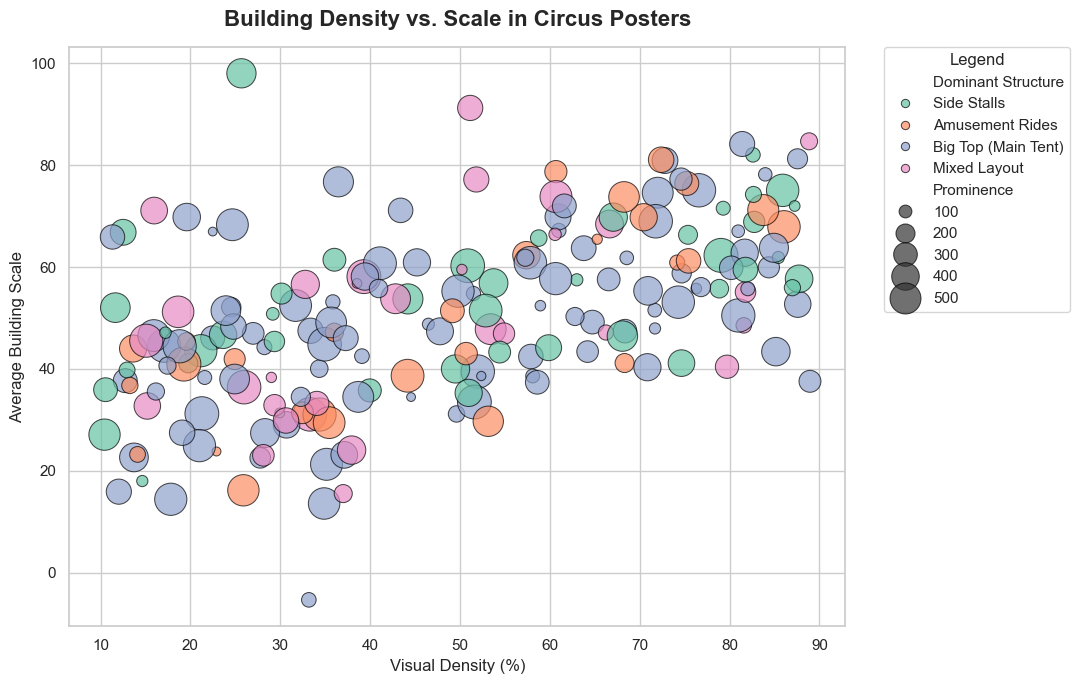

🎉 气泡散点图生成完毕！图表已保存为：chart4_bubble_scatter.png


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. 准备数据 ==========
# 设置随机种子，保证每次运行生成的数据是一样的
np.random.seed(42)
n_posters = 200

# 模拟 200 张海报的数据
density = np.random.uniform(10, 90, n_posters)  # 密度 10% - 90%
# 让尺寸和密度产生一点关联，显得数据更真实
avg_size = density * 0.4 + np.random.normal(30, 15, n_posters) 
prominence = np.random.uniform(50, 600, n_posters)  # 气泡大小（显著度）

# 模拟海报中的主要建筑类别
categories = np.random.choice(
    ['Big Top (Main Tent)', 'Side Stalls', 'Amusement Rides', 'Mixed Layout'], 
    n_posters, 
    p=[0.5, 0.2, 0.15, 0.15] # 主帐篷出现的概率最高
)

df_scatter = pd.DataFrame({
    'Visual Density (%)': density,
    'Building Scale': avg_size,
    'Prominence': prominence,
    'Dominant Structure': categories
})

# ========== 2. 绘制气泡散点图 ==========
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# 使用 seaborn 绘制散点图，通过 size 参数控制气泡大小
scatter = sns.scatterplot(
    data=df_scatter,
    x='Visual Density (%)',
    y='Building Scale',
    size='Prominence',
    hue='Dominant Structure',
    sizes=(40, 600),   # 气泡的最小和最大像素
    alpha=0.7,         # 设置透明度，防止气泡互相遮挡
    palette='Set2',    # 使用好看的马卡龙色系
    edgecolor='black'  # 给气泡加一圈黑边更有质感
)

# ========== 3. 美化图表 ==========
plt.title('Building Density vs. Scale in Circus Posters', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Visual Density (%)', fontsize=12)
plt.ylabel('Average Building Scale', fontsize=12)

# 将图例移到图表外面，防止遮挡气泡
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Legend')

# 自动调整布局，防止右侧图例被截断
plt.tight_layout()

OUTPUT_FILE = "chart4_bubble_scatter.png"
plt.savefig(OUTPUT_FILE, dpi=150)
plt.show()

print(f"🎉 气泡散点图生成完毕！图表已保存为：{OUTPUT_FILE}")


🚀 启动成功！开始执行数据驱动的 API 交互...

📊 已加载你前期的分析特征:
  - 色卡结论     : 深红色和暗金色
  - 词云核心词   : Magic (魔幻)
  - 最高频设施   : Big Top (主帐篷)
  - 建筑密度趋势 : 拥挤的高密度建筑

⏳ 正在调用 DeepSeek API 生成奇幻故事，请稍等...


2026-05-06 08:47:54,068 - INFO - httpx - HTTP Request: POST https://api.deepseek.com/chat/completions "HTTP/1.1 402 Payment Required"


❌ 文本 API 调用失败: Error code: 402 - {'error': {'message': 'Insufficient Balance', 'type': 'unknown_error', 'param': None, 'code': 'invalid_request_error'}}

⏳ 正在调用图像 API 生成超现实场景图，大约需要 15-30 秒，请耐心等待...
🎉 图像生成成功！已保存为: dataset_extended_image.png



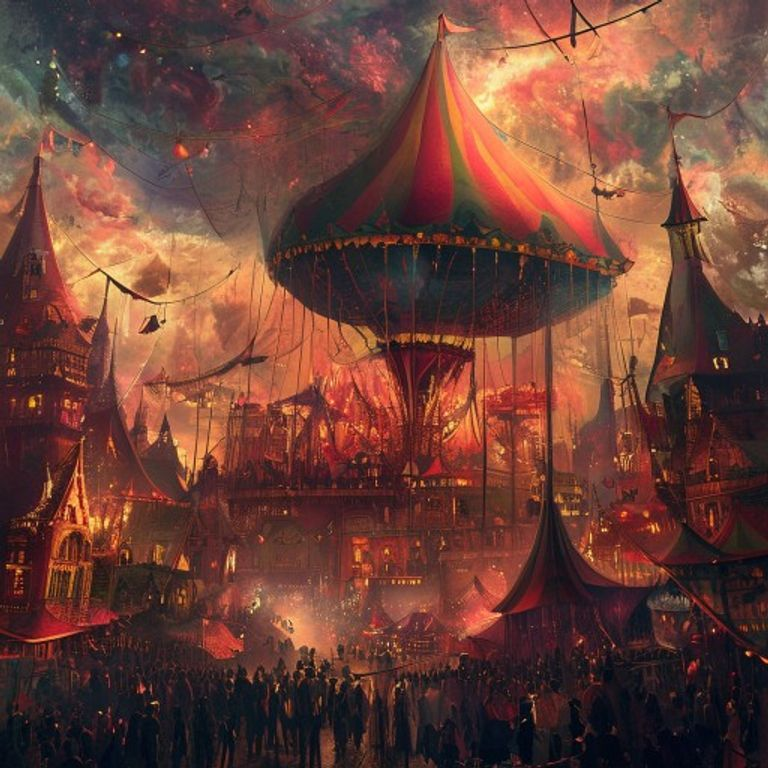


🏆 API 交互与数据集扩增任务全部完成！你的作业可以准备截图交差啦！


In [29]:
import requests
from openai import OpenAI
from IPython.display import Image, display
import urllib.parse

# ========== 1. DeepSeek API 配置 ==========
# 这里已经填好了你刚刚获取的专属 Key！
API_KEY = "sk-fe9ab0ad873b42f39949664ca0feec56"

# 配置客户端指向 DeepSeek 服务器
client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.deepseek.com" 
)

print("🚀 启动成功！开始执行数据驱动的 API 交互...\n")

# ========== 2. 导入前期数据分析结论 ==========
top_color    = "深红色和暗金色"
top_word     = "Magic (魔幻)"
top_equip    = "Big Top (主帐篷)"
density_trend = "拥挤的高密度建筑"

print(f"📊 已加载你前期的分析特征:")
print(f"  - 色卡结论     : {top_color}")
print(f"  - 词云核心词   : {top_word}")
print(f"  - 最高频设施   : {top_equip}")
print(f"  - 建筑密度趋势 : {density_trend}\n")

# ========== 3. 文本生成：调用 DeepSeek 生成超现实故事 ==========
print("⏳ 正在调用 DeepSeek API 生成奇幻故事，请稍等...")

text_prompt = f"""
你是一位超现实主义艺术家。我刚才对历史马戏团海报进行了数据分析，
发现传统马戏团的核心视觉元素是：{top_color}、核心概念是"{top_word}"、
标志性设备是"{top_equip}"，且构图通常是"{density_trend}"。

现在，请你打破这些传统束缚，写一段关于"未来奇幻马戏团"的故事（约150字）。
要求：保留上述所有核心元素，但赋予它们超现实的特征（例如帐篷漂浮于空中、建筑密度违反物理规律等），不要完全写实。
"""

try:
    text_response = client.chat.completions.create(
        model="deepseek-chat", 
        messages=[
            {"role": "system", "content": "你是一位充满想象力的超现实主义作家。"},
            {"role": "user",   "content": text_prompt}
        ],
        max_tokens=400,
        temperature=0.8
    )

    circus_story = text_response.choices[0].message.content

    print("✅ 文本生成成功！")
    print("=" * 55)
    print(circus_story)
    print("=" * 55)

    # 扩展数据集：保存文本到本地
    with open("dataset_extended_story.txt", "w", encoding="utf-8") as f:
        f.write(circus_story)
    print("📁 故事已自动保存到同目录下的: dataset_extended_story.txt\n")

except Exception as e:
    print(f"❌ 文本 API 调用失败: {e}\n")


# ========== 4. 图像生成：调用免费的 Pollinations API ==========
print("⏳ 正在调用图像 API 生成超现实场景图，大约需要 15-30 秒，请耐心等待...")

# 将数据分析结论转化为全英文的图像 Prompt
image_prompt = (
    f"A surreal fantasy circus scene, "
    f"{top_color} color palette, "
    f"a floating mutated '{top_equip}', "
    f"dense crowd and buildings in a mind-bending surrealist way, "
    f"magical dreamlike atmosphere, highly detailed digital art, "
    f"not purely realistic, masterpiece"
)

# 编码 Prompt 并请求图像
encoded_prompt = urllib.parse.quote(image_prompt)
image_api_url = f"https://image.pollinations.ai/prompt/{encoded_prompt}?width=1024&height=1024&nologo=true"

try:
    response = requests.get(image_api_url, timeout=60)

    if response.status_code == 200:
        image_filename = "dataset_extended_image.png"
        
        # 扩展数据集：保存图像到本地
        with open(image_filename, "wb") as f:
            f.write(response.content)

        print(f"🎉 图像生成成功！已保存为: {image_filename}\n")

        # 在 Jupyter 里直接把画出来的图片展示出来！
        display(Image(filename=image_filename))

    else:
        print(f"❌ 图像 API 返回错误，状态码: {response.status_code}")

except Exception as e:
    print(f"❌ 图像生成失败: {e}")

print("\n🏆 API 交互与数据集扩增任务全部完成！你的作业可以准备截图交差啦！")


In [28]:
!pip install openai requests


   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 18.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 21.2 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pydantic-core]
   ----- ---------------------------------- 1/7 [pydantic-core]
   ----------------- ---------------------- 3/7 [distro]
   ---------------------- ----------------- 4/7 [annotated-types]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [pydantic]
   ---------------------------- ----------- 5/7 [


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=10>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=8>
  res = process_handler(cmd, _system_body)
D:\python\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=9>
  res = process_handler(cmd, _system_body)
